# Assignment 2
Task Breakdown
1) Sample 10 code snippets (i.e., 5 pairs) from the task Code Clone Detection from the benchmark CodeXGlue.
2) Implement code for collecting the code embedding from an existing model CodeBERT published on Hugging Face.
3) Visualize the embedding by using TSNE technique in the library SciKit-Learn.
4) Observe the result and summarize your findings (such as “Code X and Y are close to each other in the vector space because they are semantically equivalent.“). Again, this may not be the result you actually observed!

In [6]:
# SETUP

import random
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import load_dataset
from sklearn.manifold import TSNE
from transformers import AutoModel, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


In [7]:
# Step 1: Sample 10 code snippets (5 pairs) from CodeXGLUE

DATASET_NAME = "google/code_x_glue_cc_clone_detection_big_clone_bench"
NUM_PAIRS = 5

raw = load_dataset(DATASET_NAME, split="train", streaming=True)
shuffled = raw.shuffle(seed=SEED, buffer_size=10_000)
true_clone_pairs = shuffled.filter(lambda ex: ex["label"] is True)

sampled_rows = []
for row in true_clone_pairs:
    sampled_rows.append(row)
    if len(sampled_rows) == NUM_PAIRS:
        break

# Flatten into 10 individual snippets, tracking which pair (and which side, A or B) each came from
snippets = []
for pair_idx, row in enumerate(sampled_rows):
    snippets.append({"pair": pair_idx, "side": "A", "id": row["id1"], "code": row["func1"]})
    snippets.append({"pair": pair_idx, "side": "B", "id": row["id2"], "code": row["func2"]})

print(f"Sampled {len(sampled_rows)} clone pairs ({len(snippets)} snippets total)\n")
for s in snippets:
    preview = textwrap.shorten(" ".join(s["code"].split()), width=100)
    print(f"[pair {s['pair']}{s['side']}] (func_id={s['id']}): {preview}")

Sampled 5 clone pairs (10 snippets total)

[pair 0A] (func_id=23609709): private File downloadPDB(String pdbId) { File tempFile = new File(path + "/" + pdbId + [...]
[pair 0B] (func_id=4080688): public static String getStringFromAFileAtURL(String anURL) { String htmlCode = [...]
[pair 1A] (func_id=20286589): public static void copyFile(final File source, final File target) throws [...]
[pair 1B] (func_id=6992704): public static void main(String[] args) { File file = null; try { file = [...]
[pair 2A] (func_id=6322440): public static void copyFile(final File fromFile, File toFile) throws IOException { try { if [...]
[pair 2B] (func_id=2103971): @Override protected void writeFile() { super.writeFile(); try { String tagListFilePath = [...]
[pair 3A] (func_id=7713594): private static void copyFile(File source, File dest, boolean visibleFilesOnly) throws [...]
[pair 3B] (func_id=17965575): private void readObject(ObjectInputStream in) throws IOException, ClassNotFoundException { [...]
[pair

In [8]:
# Step 2: Get embeddings from CodeBERT

MODEL_NAME = "microsoft/codebert-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()


def mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


@torch.no_grad()
def embed_code(code: str) -> np.ndarray:
    inputs = tokenizer(
        code, return_tensors="pt", truncation=True, max_length=512, padding=True
    ).to(DEVICE)
    outputs = model(**inputs)
    pooled = mean_pool(outputs.last_hidden_state, inputs["attention_mask"])
    return pooled.squeeze(0).cpu().numpy()


embeddings = np.stack([embed_code(s["code"]) for s in snippets])
print(f"Embeddings shape: {embeddings.shape}")  # (10, 768)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embeddings shape: (10, 768)


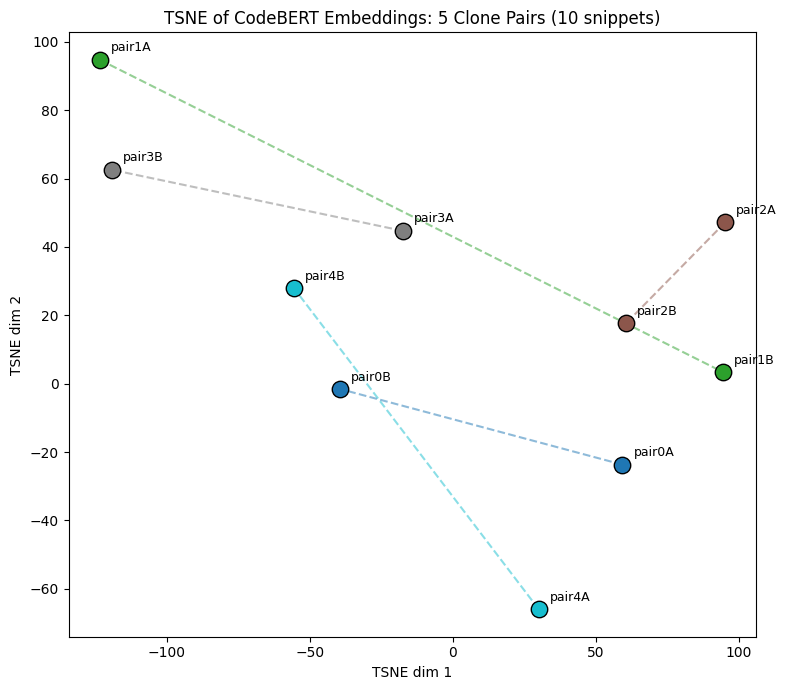

In [9]:
# Step 3: Visualize with TSNE

tsne = TSNE(
    n_components=2,
    perplexity=4,
    random_state=SEED,
    init="pca",
    learning_rate="auto",
)
coords_2d = tsne.fit_transform(embeddings)

colors = plt.cm.tab10(np.linspace(0, 1, NUM_PAIRS))

fig, ax = plt.subplots(figsize=(8, 7))
for i, s in enumerate(snippets):
    x, y = coords_2d[i]
    color = colors[s["pair"]]
    ax.scatter(x, y, color=color, s=140, edgecolor="black", zorder=3)
    ax.annotate(
        f"pair{s['pair']}{s['side']}",
        (x, y),
        textcoords="offset points",
        xytext=(8, 6),
        fontsize=9,
    )

# connect each pair's two points with a dashed line
for pair_idx in range(NUM_PAIRS):
    idx_a, idx_b = pair_idx * 2, pair_idx * 2 + 1
    ax.plot(
        [coords_2d[idx_a, 0], coords_2d[idx_b, 0]],
        [coords_2d[idx_a, 1], coords_2d[idx_b, 1]],
        color=colors[pair_idx],
        linestyle="--",
        alpha=0.5,
        zorder=1,
    )

ax.set_title("TSNE of CodeBERT Embeddings: 5 Clone Pairs (10 snippets)")
ax.set_xlabel("TSNE dim 1")
ax.set_ylabel("TSNE dim 2")
fig.tight_layout()
fig.savefig("tsne_codebert_clone_pairs.png", dpi=200)
plt.show()

In [10]:
# Step 4: Observation
# Compute pairwise cosine similarity in the 768 dimensional space just cause, and then check
# if the nearest neighbor is actually the clone partner that's labeled by CodeXGlue

from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(embeddings)
labels = [f"pair{s['pair']}{s['side']}" for s in snippets]

print("Cosine similarity matrix:\n")
header = "        " + " ".join(f"{l:>8}" for l in labels)
print(header)
for i, row_label in enumerate(labels):
    row = " ".join(f"{sim_matrix[i, j]:8.3f}" for j in range(len(labels)))
    print(f"{row_label:>8} {row}")

print("\nNearest neighbor check (excluding self):")
correct = 0
for i, s in enumerate(snippets):
    sims = sim_matrix[i].copy()
    sims[i] = -np.inf
    nn_idx = int(np.argmax(sims))
    expected_partner = i + 1 if s["side"] == "A" else i - 1
    is_match = nn_idx == expected_partner
    correct += is_match
    print(
        f"  {labels[i]}: nearest neighbor = {labels[nn_idx]} "
        f"(sim={sim_matrix[i, nn_idx]:.3f}) -> {'MATCHES labeled clone partner' if is_match else 'does NOT match labeled partner'}"
    )

print(f"\n{correct}/{len(snippets)} snippets had their labeled clone partner as nearest neighbor.")

Cosine similarity matrix:

          pair0A   pair0B   pair1A   pair1B   pair2A   pair2B   pair3A   pair3B   pair4A   pair4B
  pair0A    1.000    0.990    0.977    0.996    0.994    0.996    0.991    0.981    0.984    0.991
  pair0B    0.990    1.000    0.981    0.988    0.989    0.988    0.994    0.986    0.981    0.997
  pair1A    0.977    0.981    1.000    0.975    0.975    0.975    0.980    0.995    0.961    0.986
  pair1B    0.996    0.988    0.975    1.000    0.995    0.997    0.994    0.981    0.975    0.990
  pair2A    0.994    0.989    0.975    0.995    1.000    0.995    0.992    0.979    0.977    0.990
  pair2B    0.996    0.988    0.975    0.997    0.995    1.000    0.992    0.982    0.977    0.991
  pair3A    0.991    0.994    0.980    0.994    0.992    0.992    1.000    0.987    0.974    0.995
  pair3B    0.981    0.986    0.995    0.981    0.979    0.982    0.987    1.000    0.960    0.991
  pair4A    0.984    0.981    0.961    0.975    0.977    0.977    0.974    0.960   